## **| 비지도 학습 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch09 앙상블 학습과 랜덤 포레스트 연습문제 3, 5, 8, 10번
- 이론적 지식을 묻는 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

In [1]:
# import libraries
import numpy as np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

### **1. k-평균을 사용할 때 적절한 클러스터 개수를 선택할 수 있는 두 가지 기법을 설명하세요.**
___

1. Elbow Method(엘보 방법)
* k 값을 늘리면서 inertia(클러스터 중심과 데이터 간 거리 제곱의 합) 계산.
* k가 커질수록 inertia는 감소하지만 어느 순간 폭이 급격히 줄어드는 지점이 생김.
* 이 지점이 팔꿈치처럼 꺾이는 지점이며 적절한 k로 선택.

2. Silhouette Score (실루엣 계수)
* 각 샘플이 자기 클러스터에 얼마나 잘 속해 있는지, 다른 클러스터와 얼마나 잘 구분되는지 측정.
* 실루엣 값 범위가 1에 가까우면 매우 잘 군집됨. 0 근처는 경계에 있음, 음수는 잘못 군집됨.

### **2. 대규모 데이터셋으로 확장할 수 있는 군집 알고리즘 두 개를 말해보세요. 밀도가 높은 지역을 찾는 군집 알고리즘 두 개는 무엇인가요?**
___
대규모 데이터셋으로 확장할 수 있는 군집 알고리즘
1. Mini-Batch K-Means
* 작은 배치 데이터를 이용해 k-means를 업데이트
* 매우 큰 데이터에서도 빠르게 동작
2. BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies):
* 데이터를 한 번만 훑으면서 '클러스터링 특징 트리(CF Tree)'라는 요약 정보를 생성

밀도가 높은 지역을 찾는 군집 알고리즘
1. DBSCAN
* 밀도가 높은 영역을 클러스터로 형성
* 노이즈(outlier)를 자동으로 탐지
2. HDBSCAN (Hierarchical DBSCAN):
* DBSCAN의 확장판으로, 다양한 밀도를 가진 데이터셋에서도 잘 작동

### **3. 가우시안 혼합이 무엇인가요? 어떤 작업에 사용할 수 있나요?**
___

가우시안 혼합 모델은 데이터가 여러 개의 가우시안 분포가 섞여서 생성되었다고 가정하는 확률 모델. 군집화나 밀도추정, 이상치 탐지 등에 사용될 수 있다.

### **4. 다음 단계를 따라 올리베티 얼굴 데이터셋을 군집해보자..**
___
전통적인 올리베티 얼굴 데이터셋은 64 X 64 픽셀 크기의 흑백 얼굴 이미지 400개를 가지고 있습니다. 사람 40명의 사진을 10장씩 찍은 것인데, 각 이미지는 4096 크기의 1D 벡터로 펼쳐져 있습니다.

#### **STEP 1. 아래 코드를 실행하여 데이터셋을 불러오세요.**

In [2]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


####  **STEP 2. 데이터셋을 훈련 세트, 검증 세트, 테스트 세트로 나누세요.**
해당 데이터셋은 매우 작으므로, `StratifiedShuffleSplit` 함수를 이용하여, 계층적 샘플링으로 각 세트에 동일한 사람의 얼굴이 고루 섞이도록 하세요.

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

# 훈련(60%) / 임시(40%) 분할
split = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
for train_index, temp_index in split.split(olivetti.data, olivetti.target):
    X_train, y_train = olivetti.data[train_index], olivetti.target[train_index]
    X_temp, y_temp = olivetti.data[temp_index], olivetti.target[temp_index]

# 임시(40%)를 검증(20%)과 테스트(20%)로 분할
split_val_test = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
for val_index, test_index in split_val_test.split(X_temp, y_temp):
    X_valid, y_valid = X_temp[val_index], y_temp[val_index]
    X_test, y_test = X_temp[test_index], y_temp[test_index]

####  **STEP 3. 속도를 높이기 위해 각 학습/검증/테스트 피처 데이터셋에 PCA을 적용하여 데이터의 차원을 줄이세요.**
- `n_componets = 0.99`로 설정합니다.

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

print(f"원본 차원: {X_train.shape[1]}")
print(f"축소된 차원: {X_train_pca.shape[1]}")

원본 차원: 4096
축소된 차원: 177


####  **STEP 4. 교재에서 다룬 방법을 사용하여 적절한 클러스터 개수를 찾고 k-평균을 사용해 이미지를 군집해보세요.**

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 실루엣 점수 계산 (범위: 20~100)
ks = range(20, 101, 10)
scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)
    score = silhouette_score(X_train_pca, kmeans.labels_)
    scores.append(score)

# 최적의 k 선택 (점수가장 높은 지점)
best_k = ks[scores.index(max(scores))]
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X_train_pca)

####  **STEP 5. 아래 `plot_faces` 함수를 이용하여, 클러스터를 시각화하고, 각 클러스터에 비슷한 얼굴이 들어있는지 확인해보세요.**

In [8]:
# plot_faces 함수
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

Cluster 0 시각화:


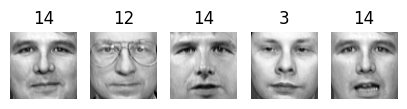

In [9]:
# 예시: 0번 클러스터에 속한 얼굴들 시각화
cluster_id = 0
X_cluster = X_train[y_pred == cluster_id]
y_cluster = y_train[y_pred == cluster_id]

print(f"Cluster {cluster_id} 시각화:")
plot_faces(X_cluster, y_cluster)